In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("Final dataset with mac vari.csv")
#df = pd.read_csv("Dataset (3).csv")
df = df.dropna()

In [3]:
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

In [4]:
X_train_v = train.drop(columns=["Date","Newsenti","volatility", "garch_volatility","vol_1"], errors="ignore")
X_test_v = test.drop(columns=["Date","Newsenti","volatility", "garch_volatility","vol_1"], errors="ignore")

In [5]:
y_train_v = train["volatility"]
y_test_v = test["volatility"]

In [6]:
rf_vol = RandomForestRegressor(n_estimators=200, random_state=42)
rf_vol.fit(X_train_v, y_train_v)

RandomForestRegressor(n_estimators=200, random_state=42)

In [7]:
y_pred_vol = rf_vol.predict(X_test_v)

In [8]:
r2_vol = r2_score(y_test_v, y_pred_vol)
rmse_vol = np.sqrt(mean_squared_error(y_test_v, y_pred_vol))
mae_vol = mean_absolute_error(y_test_v, y_pred_vol)

In [9]:
print("Random Forest on volatility")
print("R2:", r2_vol)
print("RMSE:", rmse_vol)
print("MAE:", mae_vol)

Random Forest on volatility
R2: -0.31727125271512713
RMSE: 0.005100154003609044
MAE: 0.0038319275508187133


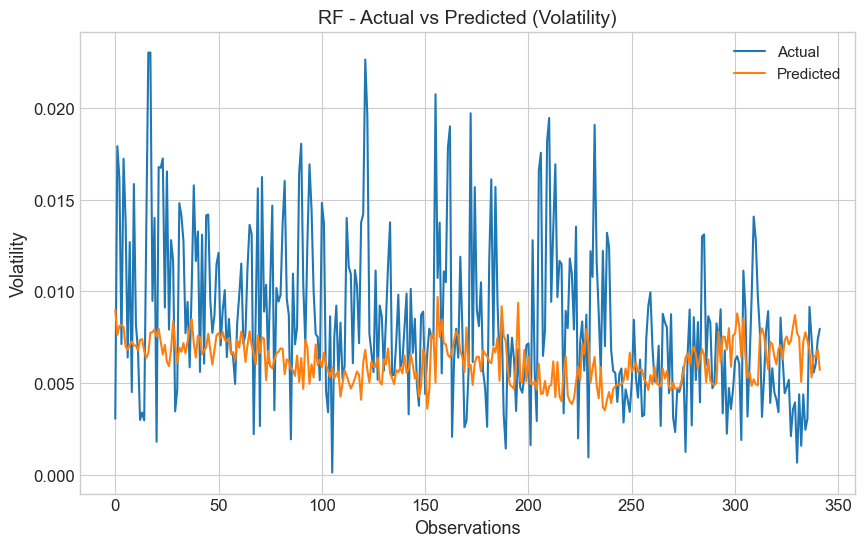

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look

plt.rcParams.update({
    "font.size": 12,
    "figure.figsize": (10, 6),
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11
})
plt.figure()
plt.plot(y_test_v.values, label="Actual")
plt.plot(y_pred_vol, label="Predicted")
plt.title("RF - Actual vs Predicted (Volatility)")
plt.xlabel("Observations")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [11]:
X_train_g = train.drop(columns=["Date","Newsenti","garch_volatility", "volatility","vol_1"], errors="ignore")
X_test_g = test.drop(columns=["Date","Newsenti","garch_volatility", "volatility","vol_1"], errors="ignore")

In [12]:
y_train_g = train["garch_volatility"]
y_test_g = test["garch_volatility"]

In [13]:
rf_garch = RandomForestRegressor(n_estimators=200, random_state=42)
rf_garch.fit(X_train_g, y_train_g)

RandomForestRegressor(n_estimators=200, random_state=42)

In [14]:
y_pred_garch = rf_garch.predict(X_test_g)

In [15]:
r2_garch = r2_score(y_test_g, y_pred_garch)
rmse_garch = np.sqrt(mean_squared_error(y_test_g, y_pred_garch))
mae_garch = mean_absolute_error(y_test_g, y_pred_garch)

In [16]:
print(" Random Forest on GARCH volatility ")
print("R2:", r2_garch)
print("RMSE:", rmse_garch)
print("MAE:", mae_garch)

 Random Forest on GARCH volatility 
R2: -0.709982981762338
RMSE: 0.12206540790543122
MAE: 0.08761347373165207


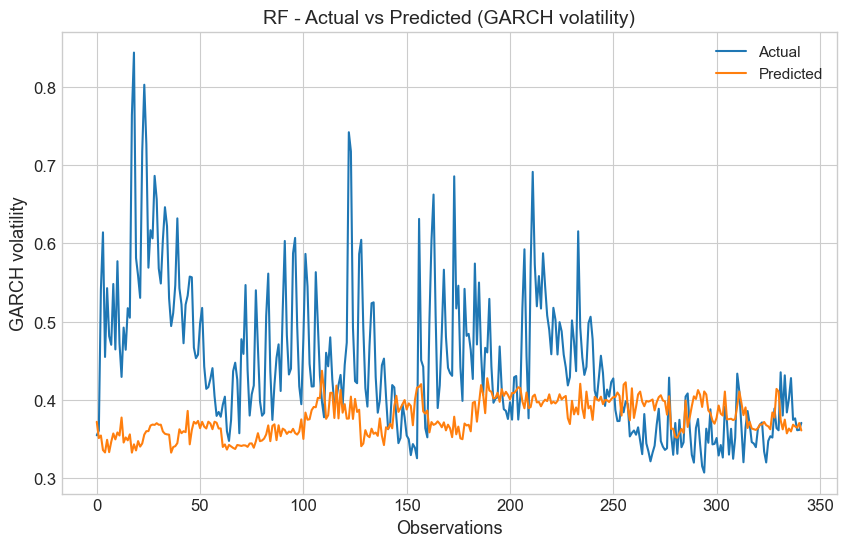

In [17]:
plt.figure()
plt.plot(y_test_g.values, label="Actual")
plt.plot(y_pred_garch, label="Predicted")
plt.title("RF - Actual vs Predicted (GARCH volatility)")
plt.xlabel("Observations")
plt.ylabel("GARCH volatility")
plt.legend()
plt.show()

In [18]:
df = df.sort_values(by='Date').reset_index(drop=True)
#df = df.drop(columns=['sentiment','Newsenti'])
Y = df['volatility']
X = df.drop(columns=["Date","Newsenti",'volatility','garch_volatility'])

In [19]:
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)

# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()

X = data.drop(columns=['volatility'])
Y = data['volatility']

In [20]:
n = len(X)

splits = [int(0.80 * n),int(0.85 * n),int(0.90 * n),int(0.95 * n)]

In [21]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # Directional Accuracy
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)

    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": directional_accuracy
    })

    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)
results_df = pd.DataFrame(results)


    Split 1
    Train Size: 1365
    Test Size: 342
    MSE: 0.0000
    MAE: 0.0036
    R2: 0.0012
    Directional Accuracy: 0.7632
    

    Split 2
    Train Size: 1450
    Test Size: 257
    MSE: 0.0000
    MAE: 0.0036
    R2: -0.0227
    Directional Accuracy: 0.7588
    

    Split 3
    Train Size: 1536
    Test Size: 171
    MSE: 0.0000
    MAE: 0.0036
    R2: 0.0157
    Directional Accuracy: 0.7661
    

    Split 4
    Train Size: 1621
    Test Size: 86
    MSE: 0.0000
    MAE: 0.0035
    R2: -0.0328
    Directional Accuracy: 0.7674
    


In [22]:
df = df.sort_values(by='Date').reset_index(drop=True)
Y = df['garch_volatility']
X = df.drop(columns=["Date","Newsenti",'garch_volatility'])

In [23]:
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)

# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()
X = data.drop(columns=['garch_volatility'])
Y = data['garch_volatility']

In [24]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # Directional Accuracy
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)

    results.append({
        "Split": i+1,
        "Train Size": split,
        "Test Size": len(Y_test),
        "MSE": mse,
        "MAE": mae,
        "R2": r2,
        "Directional Accuracy": directional_accuracy
    })

    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)
results_df = pd.DataFrame(results)


    Split 1
    Train Size: 1365
    Test Size: 342
    MSE: 0.0088
    MAE: 0.0661
    R2: 0.5205
    Directional Accuracy: 0.8567
    

    Split 2
    Train Size: 1450
    Test Size: 257
    MSE: 0.0086
    MAE: 0.0650
    R2: 0.5236
    Directional Accuracy: 0.8755
    

    Split 3
    Train Size: 1536
    Test Size: 171
    MSE: 0.0096
    MAE: 0.0666
    R2: 0.4913
    Directional Accuracy: 0.8830
    

    Split 4
    Train Size: 1621
    Test Size: 86
    MSE: 0.0082
    MAE: 0.0628
    R2: 0.5575
    Directional Accuracy: 0.8256
    


In [25]:
results_df = pd.DataFrame(results)
print(results_df)

   Split  Train Size  Test Size       MSE       MAE        R2  \
0      1        1365        342  0.008789  0.066056  0.520539   
1      2        1450        257  0.008593  0.064974  0.523563   
2      3        1536        171  0.009581  0.066621  0.491303   
3      4        1621         86  0.008161  0.062845  0.557470   

   Directional Accuracy  
0              0.856725  
1              0.875486  
2              0.883041  
3              0.825581  
